Column names before cleaning: Index(['edition', 'start_date', 'winner_name', 'winner_team', 'distance',
       'time_overall', 'time_margin', 'stage_wins', 'stages_led', 'height',
       'weight', 'age', 'born', 'died', 'full_name', 'nickname', 'birth_town',
       'birth_country', 'nationality'],
      dtype='object')
Column names after cleaning: Index(['edition', 'start_date', 'winner_name', 'winner_team', 'distance',
       'time_overall', 'time_margin', 'stage_wins', 'stages_led', 'height',
       'weight', 'age', 'born', 'died', 'full_name', 'nickname', 'birth_town',
       'birth_country', 'nationality'],
      dtype='object')


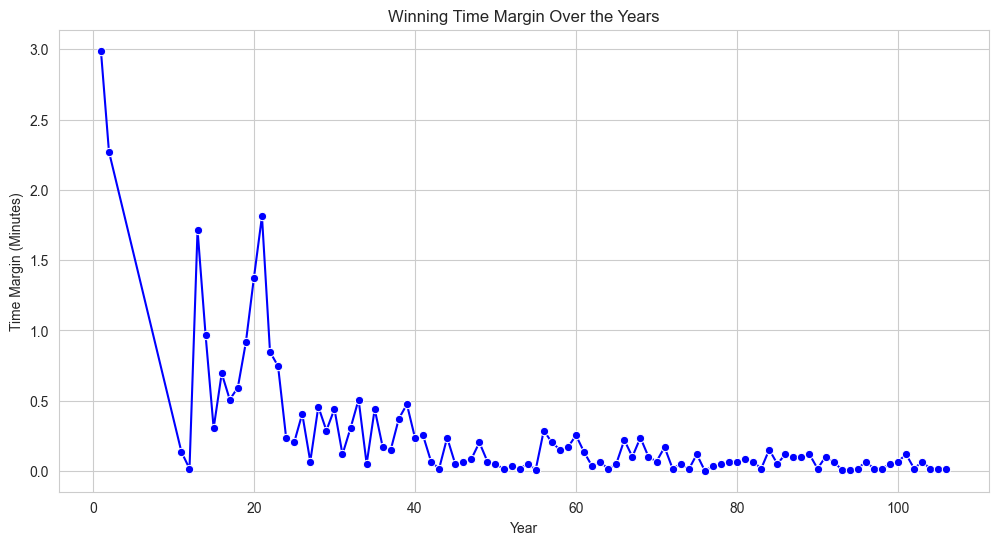

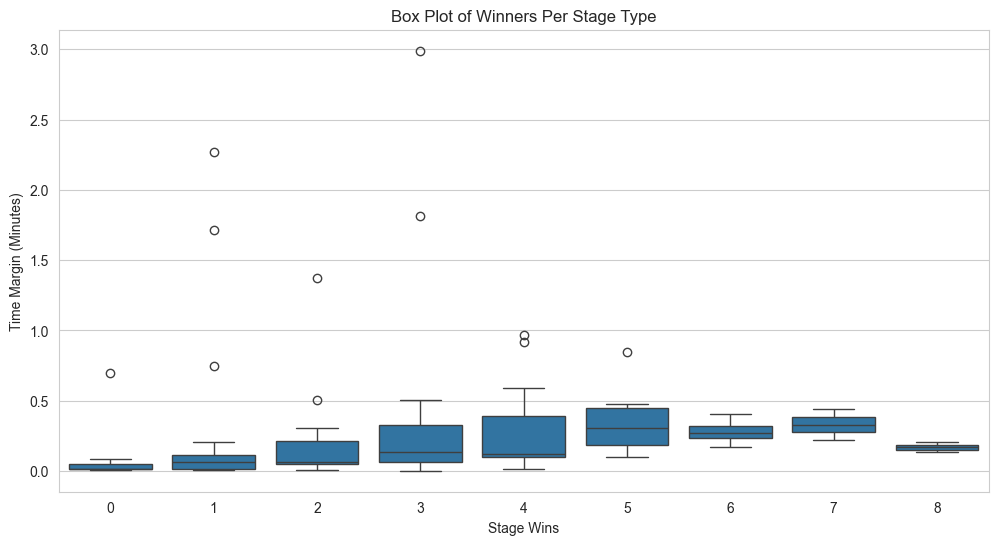

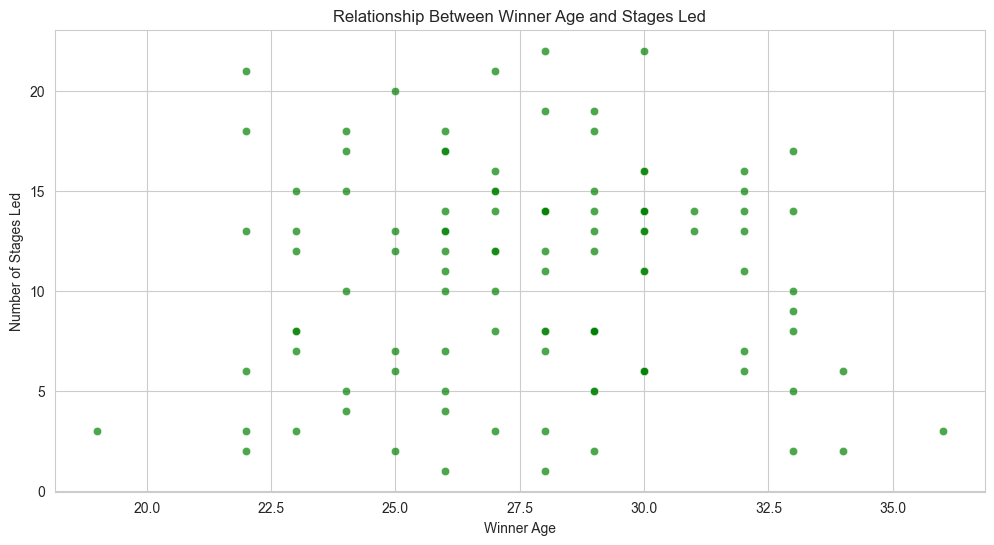

C:\Users\User\AppData\Local\Temp\ipykernel_10728\3551675235.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nationalities.index, y=top_nationalities.values, palette="mako")


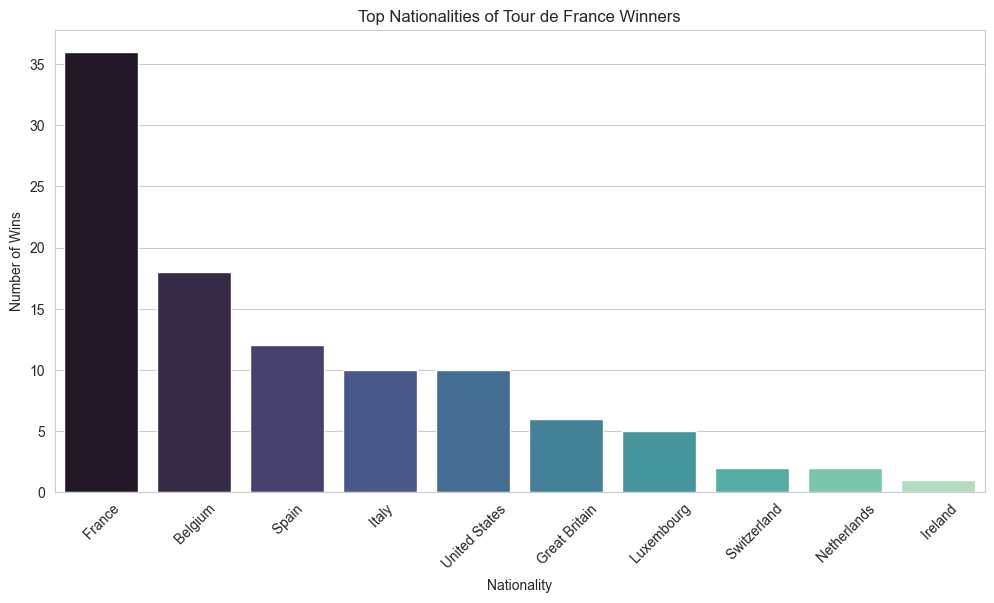

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-04-07/tdf_winners.csv"
df = pd.read_csv(url)

# Display column names to check for inconsistencies
print("Column names before cleaning:", df.columns)

# Standardize column names: lowercase, remove spaces
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Print cleaned column names
print("Column names after cleaning:", df.columns)

# Convert necessary columns to numeric values (handling errors)
df['time_margin'] = pd.to_numeric(df['time_margin'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['stages_led'] = pd.to_numeric(df['stages_led'], errors='coerce')

# Set Seaborn style for better visuals
sns.set_style("whitegrid")

# ----------------------------------------------
# 1️⃣ Winning Time Margin Over the Years
# ----------------------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(x=df['edition'], y=df['time_margin'], marker='o', color='b')
plt.xlabel('Year')
plt.ylabel('Time Margin (Minutes)')
plt.title('Winning Time Margin Over the Years')
plt.show()

# ----------------------------------------------
# 2️⃣ Box Plot of Winners Per Stage Type
# ----------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['stage_wins'], y=df['time_margin'])
plt.xlabel("Stage Wins")
plt.ylabel("Time Margin (Minutes)")
plt.title("Box Plot of Winners Per Stage Type")
plt.show()

# ----------------------------------------------
# 3️⃣ Relationship Between Winner Age and Stages Led
# ----------------------------------------------
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['age'], y=df['stages_led'], alpha=0.7, color='g')
plt.xlabel('Winner Age')
plt.ylabel('Number of Stages Led')
plt.title('Relationship Between Winner Age and Stages Led')
plt.show()

# ----------------------------------------------
# 4️⃣ Top Nationalities of Recent Winners
# ----------------------------------------------
# Sort by most recent winners and count top nationalities
top_nationalities = df['nationality'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_nationalities.index, y=top_nationalities.values, palette="mako")
plt.xlabel("Nationality")
plt.ylabel("Number of Wins")
plt.title("Top Nationalities of Tour de France Winners")
plt.xticks(rotation=45)
plt.show()
